In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider


In [2]:
def visualize_voxel(cell):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(projection='3d')

    # 表示するボクセル（0以外）
    filled = cell > 0

    # 色設定（0:透明, 1:青, 2:赤）
    colors = np.empty(cell.shape, dtype=object)
    colors[cell == 1] = 'blue'   # 細胞質
    colors[cell == 2] = 'red'    # 核

    ax.voxels(filled, facecolors=colors, edgecolor='k')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    plt.show()


ValueError: You must provide facecolors, edgecolors, or both for shade to work.

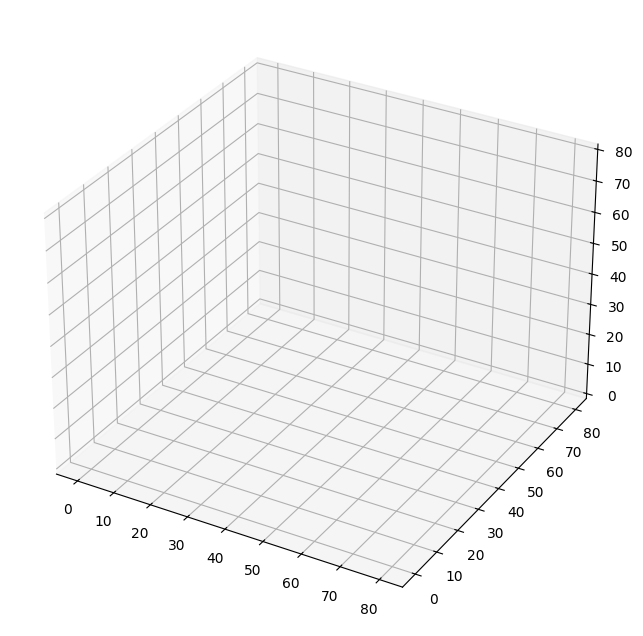

In [5]:
# 実行
visualize_voxel(cell)

In [13]:
import numpy as np

def generate_voronoi_cells(
    grid_size=100,
    sphere_radius=40,
    num_cells=50,
    nucleus_ratio=0.3,
    nucleus_offset_ratio=0.5,
    seed=0
):
    np.random.seed(seed)

    cell = np.zeros((grid_size, grid_size, grid_size), dtype=np.uint8)
    center = np.array([grid_size // 2] * 3)

    # 球内マスク
    xs, ys, zs = np.indices((grid_size, grid_size, grid_size))
    coords = np.stack([xs, ys, zs], axis=-1)
#    dist_from_center = np.linalg.norm(coords - center, axis=-1)
#    sphere_mask = dist_from_center <= sphere_radius
    
    # 距離
    dist_from_center = np.linalg.norm(coords - center, axis=-1)
    
    # ノイズ生成（滑らかな乱れ）
    noise = np.random.normal(0, 1, size=dist_from_center.shape)
    
    # 平滑化（ここが重要）
    from scipy.ndimage import gaussian_filter
    #noise = gaussian_filter(noise, sigma=5)
    noise = gaussian_filter(np.random.normal(size=dist_from_center.shape), sigma=6)
    
    # スケール調整（凹凸の強さ）
    noise = noise / noise.std() * (sphere_radius * 0.05)
    
    # 半径にノイズを加える
#    deformed_radius = sphere_radius + noise
    deformed_radius = sphere_radius * (1 + 0.15 * noise)
    
    # マスク生成
#    sphere_mask = dist_from_center <= deformed_radius
    sphere_mask = dist_from_center <= deformed_radius

    # 細胞中心
    seeds = []
    while len(seeds) < num_cells:
        p = np.random.randint(0, grid_size, size=3)
        if np.linalg.norm(p - center) <= sphere_radius:
            seeds.append(p)
    seeds = np.array(seeds)

    # ボロノイ分割
    flat_coords = coords.reshape(-1, 3)
    dists = np.linalg.norm(flat_coords[:, None, :] - seeds[None, :, :], axis=2)
    labels = np.argmin(dists, axis=1).reshape(grid_size, grid_size, grid_size)

    # 各細胞ごと処理
    for i in range(num_cells):
        mask = (labels == i) & sphere_mask
        indices = np.argwhere(mask)

        if len(indices) == 0:
            continue

        centroid = indices.mean(axis=0)
        dists = np.linalg.norm(indices - centroid, axis=1)
        r_cell = dists.max()

#        direction = np.random.normal(size=3)
#        direction /= np.linalg.norm(direction)
        direction = coords - center
        direction = direction / (np.linalg.norm(direction, axis=-1, keepdims=True) + 1e-8)


        
#        offset = direction * r_cell * nucleus_offset_ratio
#        scale = np.random.uniform(0.0, nucleus_offset_ratio)
#        offset = direction * r_cell * scale
#        nucleus_center = centroid + offset

        r_nucleus = r_cell * nucleus_ratio

        max_offset = r_cell - r_nucleus
        scale = (np.random.uniform(0.0, 1.0))**2  # 中心寄り分布

        offset = direction * max_offset * scale
        nucleus_center = centroid + offset

####################333
        
#direction = np.random.normal(size=3)
#direction /= np.linalg.norm(direction)

#r_nucleus = r_cell * nucleus_ratio

#max_offset = r_cell - r_nucleus
#scale = (np.random.uniform(0.0, 1.0))**2  # 中心寄り分布

#offset = direction * max_offset * scale
#nucleus_center = centroid + offset



########################33


        
        for idx in indices:
            d = np.linalg.norm(idx - nucleus_center)

            if d <= r_nucleus:
                cell[tuple(idx)] = 2  # 核
            else:
                cell[tuple(idx)] = 1  # 細胞質

    # -------------------------
    # 細胞膜の追加（ここが新規）
    # -------------------------
    membrane = np.zeros_like(cell, dtype=bool)

    # 26近傍方向
    directions = [
        (1,0,0), (-1,0,0),
        (0,1,0), (0,-1,0),
        (0,0,1), (0,0,-1),
        (1,1,0), (1,-1,0), (-1,1,0), (-1,-1,0),
        (1,0,1), (1,0,-1), (-1,0,1), (-1,0,-1),
        (0,1,1), (0,1,-1), (0,-1,1), (0,-1,-1),
        (1,1,1), (1,1,-1),
        (1,-1,1), (-1,1,1),
        (1,-1,-1), (-1,1,-1),
        (-1,-1,1), (-1,-1,-1)
    ]

    for dx, dy, dz in directions:
        shifted = np.roll(labels, shift=(dx, dy, dz), axis=(0,1,2))
        boundary = (labels != shifted) & sphere_mask
        membrane |= boundary

    # 膜を上書き（核や細胞質より優先）
    cell[membrane] = 3

    # 球外は0
    cell[~sphere_mask] = 0

    # -------------------------
    # 外周（細胞外との境界）にも膜を追加
    # -------------------------
    outer_membrane = np.zeros_like(cell, dtype=bool)

    for dx, dy, dz in directions:
        shifted_mask = np.roll(sphere_mask, shift=(dx, dy, dz), axis=(0,1,2))
        boundary_outer = sphere_mask & (~shifted_mask)
        outer_membrane |= boundary_outer

    # 膜に追加（核は上書きしない場合）
    #cell[(outer_membrane) & (cell != 2)] = 3
    cell[(outer_membrane)] = 3
    
    return cell


# 実行例
cell = generate_voronoi_cells(
    grid_size=80,
    sphere_radius=30,
    num_cells=40,
    nucleus_ratio=0.2,
    nucleus_offset_ratio=0.3
)

print(cell.shape)
print("値:", np.unique(cell))

np.save("cell.npy", cell)


(80, 80, 80)
値: [0 1 3]


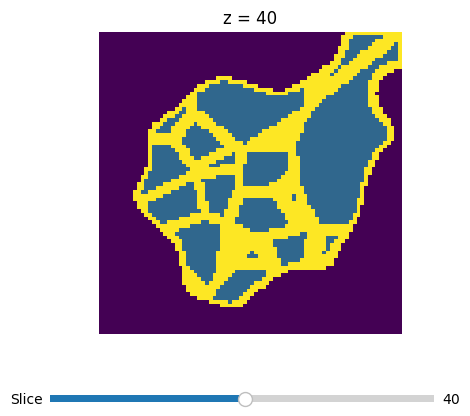

In [15]:
interactive_slice(cell)

In [14]:
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import numpy as np

def interactive_slice(cell):
    fig, ax = plt.subplots()
    plt.subplots_adjust(bottom=0.25)

    idx = cell.shape[2] // 2
    img = ax.imshow(cell[:, :, idx], cmap='viridis')
    ax.set_title(f'z = {idx}')
    ax.axis('off')

    ax_slider = plt.axes([0.2, 0.1, 0.6, 0.03])
    slider = Slider(ax_slider, 'Slice', 0, cell.shape[2]-1,
                    valinit=idx, valstep=1)

    def update(val):
        i = int(slider.val)
        img.set_data(cell[:, :, i])
        ax.set_title(f'z = {i}')
        fig.canvas.draw_idle()

    slider.on_changed(update)
    plt.show()


# 実行
#cell = np.load("cell.npy")
#interactive_slice(cell)

(80, 80, 80)
値: [0 1 2 3]


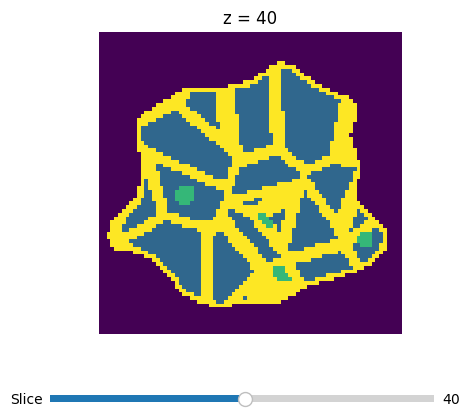

In [16]:
import numpy as np
from scipy.ndimage import gaussian_filter

def generate_realistic_cells(
    grid_size=80,
    sphere_radius=30,
    num_cells=40,
    nucleus_ratio=0.2,
    seed=0
):
    np.random.seed(seed)

    cell = np.zeros((grid_size, grid_size, grid_size), dtype=np.uint8)
    center = np.array([grid_size // 2] * 3)

    # =========================
    # ① 凹凸のある外形（重要）
    # =========================
    xs, ys, zs = np.indices((grid_size, grid_size, grid_size))
    coords = np.stack([xs, ys, zs], axis=-1)

    dist_from_center = np.linalg.norm(coords - center, axis=-1)

    noise = np.random.normal(0, 1, size=dist_from_center.shape)
    noise = gaussian_filter(noise, sigma=6)

    noise = noise / noise.std() * (sphere_radius * 0.12)

    deformed_radius = sphere_radius + noise
    sphere_mask = dist_from_center <= deformed_radius

    # =========================
    # ② ボロノイ種点
    # =========================
    seeds = []
    while len(seeds) < num_cells:
        p = np.random.randint(0, grid_size, size=3)
        if sphere_mask[tuple(p)]:
            seeds.append(p)
    seeds = np.array(seeds)

    # =========================
    # ③ ボロノイ分割
    # =========================
    flat_coords = coords.reshape(-1, 3)
    dists = np.linalg.norm(flat_coords[:, None, :] - seeds[None, :, :], axis=2)
    labels = np.argmin(dists, axis=1).reshape(grid_size, grid_size, grid_size)

    # =========================
    # ④ 核＋細胞質
    # =========================
    for i in range(num_cells):
        mask = (labels == i) & sphere_mask
        indices = np.argwhere(mask)

        if len(indices) == 0:
            continue

        centroid = indices.mean(axis=0)
        dists = np.linalg.norm(indices - centroid, axis=1)
        r_cell = dists.max()

        # 核（中心寄りランダム）
        direction = np.random.normal(size=3)
        direction /= np.linalg.norm(direction)

        r_nucleus = r_cell * nucleus_ratio
        max_offset = r_cell - r_nucleus

        scale = (np.random.uniform(0, 1))**2  # 中心寄り
        offset = direction * max_offset * scale

        nucleus_center = centroid + offset

        for idx in indices:
            d = np.linalg.norm(idx - nucleus_center)

            if d <= r_nucleus:
                cell[tuple(idx)] = 2
            else:
                cell[tuple(idx)] = 1

    # =========================
    # ⑤ 細胞膜（内部境界）
    # =========================
    membrane = np.zeros_like(cell, dtype=bool)

    directions = [
        (1,0,0), (-1,0,0),
        (0,1,0), (0,-1,0),
        (0,0,1), (0,0,-1),
        (1,1,0), (1,-1,0), (-1,1,0), (-1,-1,0),
        (1,0,1), (1,0,-1), (-1,0,1), (-1,0,-1),
        (0,1,1), (0,1,-1), (0,-1,1), (0,-1,-1)
    ]

    for dx, dy, dz in directions:
        shifted = np.roll(labels, shift=(dx, dy, dz), axis=(0,1,2))
        boundary = (labels != shifted) & sphere_mask
        membrane |= boundary

    # =========================
    # ⑥ 外周膜（凹凸形状に対応）
    # =========================
    outer_membrane = np.zeros_like(cell, dtype=bool)

    for dx, dy, dz in directions:
        shifted_mask = np.roll(sphere_mask, shift=(dx, dy, dz), axis=(0,1,2))
        boundary_outer = sphere_mask & (~shifted_mask)
        outer_membrane |= boundary_outer

    # =========================
    # ⑦ 書き込み順（重要）
    # =========================
    cell[~sphere_mask] = 0
    cell[(membrane | outer_membrane) & (cell != 2)] = 3

    return cell


# =========================
# 実行
# =========================
cell = generate_realistic_cells()

print(cell.shape)
print("値:", np.unique(cell))

np.save("cell.npy", cell)
interactive_slice(cell)

In [17]:
np.save("cell.npy", cell)